In [32]:
import os
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from labmate.acquisition_notebook import AcquisitionAnalysisManager


In [47]:
# path_folder_data = r"./data/data_temp_SHG/temp_scan 04 29"
path_folder_data = r"./data/data_temp_SHG/temp_scan 05 05"
folder_data_files = os.listdir(path_folder_data)
print(folder_data_files)

['temp.json', 'temperature_scan']


In [48]:
# fine data scan :
name_exp = 'temperature_scan'
# name = "2026_04_29__15_59_36__temperature_scan.h5"
name = "2026_05_05__08_48_24__temperature_scan.h5"
full_path = os.path.join(path_folder_data, name_exp, name)
aqm = AcquisitionAnalysisManager( os.path.join(path_folder_data, name_exp))
aqm.analysis_cell(filename=full_path)

print(aqm.data)

INFO:2026_05_05__08_48_24__temperature_scan


AnalysisData (rw) (not saved): 
 {
    "acquisition_cell" (r): {
        "1": "variable of type str"
    },
    "experiment_name" (r): "variable of type str",
    "info" (r): {
        "acquisition_duration": "1.079e+03 (type : float64)",
        "logs": "variable of type str",
        "prints": "variable of type str"
    },
    "list_SHG_errors" (r): "shape: (61,) (type: ndarray)",
    "list_SHG_powers" (r): "shape: (61,) (type: ndarray)",
    "list_Terrors" (r): "shape: (61,) (type: ndarray)",
    "list_Tmeas" (r): "shape: (61,) (type: ndarray)",
    "pump_power_mW" (r): "300 (type : int64)",
    "useful" (r): "variable of type bool"
}


In [49]:
list_T = np.array(aqm.data['list_Tmeas'])
list_P = np.array(aqm.data['list_SHG_powers'])
list_Perr = np.array(aqm.data['list_SHG_errors'])
list_Terr = np.array(aqm.data['list_Terrors'])

In [50]:
# Quasi-phase-matching fit function
def qpm_fit(T, I0, T0, dT, B):
    """
    A_fit = I0 * sinc^2( (T - T0) / dT ) + B
    """
    x = (T - T0) / dT
    return I0 * ((np.sinc(x))**2) + B

In [51]:
# Generate fit data
# ---- initial guess ----
p0 = [
    np.max(list_P) - np.min(list_P),        # amplitude
    list_T[np.argmax(list_P)],              # center
(np.max(list_T)-np.min(list_T))/10,         # width guess
    np.min(list_P)                          # background
]

# ---- weighted fit ----
popt, pcov = curve_fit(
    qpm_fit,
    list_T, list_P,
    p0=p0,
    sigma=list_Perr,
    absolute_sigma=True
)

Tfit = np.linspace(np.min(list_T), np.max(list_T), 500)
# Find temperature at maximum SHG power from fit
T_fit_max = popt[1]  # T0 from fit parameters
print(f"Estimated temperature for maximum SHG power: {T_fit_max:.2f} °C")


Estimated temperature for maximum SHG power: 44.89 °C


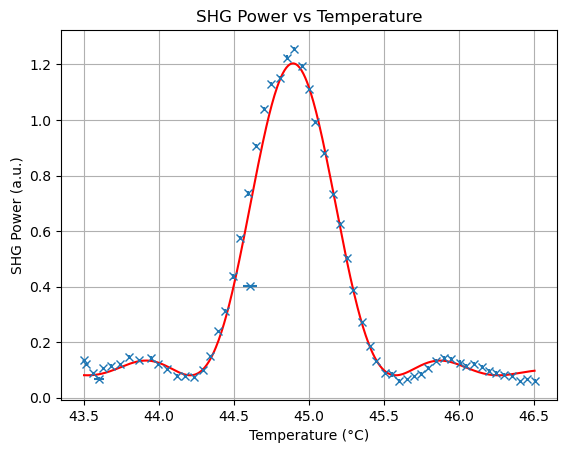

In [52]:
plt.errorbar(list_T, list_P , xerr=list_Terr, yerr=list_Perr, fmt='x', label='data')
plt.plot(Tfit, qpm_fit(Tfit, *popt), 'r-', label='fit')
plt.xlabel('Temperature (°C)')
plt.ylabel('SHG Power (a.u.)')
plt.title('SHG Power vs Temperature')
plt.grid()
plt.show()
